# Step 3b: Random Forest Baseline + Feature Importance

**Goal:** Compare Random Forest vs Ridge regression, analyze feature importance

**Tasks:**
- [x] Train RF with simple hyperparameter search
- [x] **Train RF with cross-validation for robust estimates**
- [x] Compare Ridge vs RF metrics (MAE, RMSE)
- [x] Compute and plot top-15 feature importances
- [x] Save feature importance to outputs/

**Contents:**
1. Load Data and Define Splits
2. Train Ridge Baseline (Reference)
3. Random Forest Hyperparameter Search
4. **Cross-Validation Training**
5. Ridge vs Random Forest Comparison
6. Feature Importance Analysis

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import load_batches
from src.domain_splits import get_control_mode_split
from src.baseline_model import train_and_evaluate_baseline, RidgeBaseline
from src.rf_baseline import (
    RandomForestBaseline,
    train_and_evaluate_rf_baseline,
    compute_permutation_importance,
    get_feature_importance_ranking,
)

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
window_fraction = 0.9 # fraction of total exp time until crop prediction window

## 1. Load Data and Define Splits

In [3]:
# Load batches
batches = load_batches()
print(f"Loaded {len(batches)} batches")

# Get domain split (1b: Recipe vs APC)
split = get_control_mode_split("1c")
source_ids = split["source"]  # 1-30
target_ids = split["target"]  # 61-90

# Split source into train/val
np.random.seed(42)
source_shuffled = np.random.permutation(source_ids)
n_val = int(len(source_ids) * 0.2)
val_ids = list(source_shuffled[:n_val])
train_ids = list(source_shuffled[n_val:])

print(f"Train: {len(train_ids)} batches")
print(f"Val: {len(val_ids)} batches")
print(f"Target: {len(target_ids)} batches")

Loaded 100 batches
Train: 48 batches
Val: 12 batches
Target: 30 batches


## 2. Train Ridge Baseline (Reference)

In [4]:
ridge_results = train_and_evaluate_baseline(
    batches,
    train_ids=train_ids,
    val_ids=val_ids,
    target_ids=target_ids,
    alpha=10,
    window_fraction=window_fraction,
)

print("Ridge Regression Results")
print(f"  Train MAE: {ridge_results['train']['mae']:.3f}")
print(f"  Val MAE:   {ridge_results['val']['mae']:.3f}")
print(f"  Target MAE: {ridge_results['target']['mae']:.3f}")

Ridge Regression Results
  Train MAE: 0.685
  Val MAE:   1.647
  Target MAE: 3.966


## 3. Random Forest Hyperparameter Search

In [19]:
# Simple grid search over hyperparameters
param_grid = [
    {"n_estimators": 10, "max_depth": 2, "min_samples_leaf": 3},
    {"n_estimators": 20, "max_depth": 2, "min_samples_leaf": 4},
    {"n_estimators": 50, "max_depth": 2, "min_samples_leaf": 3},
    {"n_estimators": 10, "max_depth": 3, "min_samples_leaf": 5},
    {"n_estimators": 20, "max_depth": 3, "min_samples_leaf": 3},
    {"n_estimators": 50, "max_depth": 3, "min_samples_leaf": 4},
    {"n_estimators": 10, "max_depth": 5, "min_samples_leaf": 3},
    {"n_estimators": 20, "max_depth": 5, "min_samples_leaf": 5},
    {"n_estimators": 30, "max_depth": 3, "min_samples_leaf": 5},
    {"n_estimators": 100, "max_depth": 1, "min_samples_leaf": 5},
    {"n_estimators": 100, "max_depth": 2, "min_samples_leaf": 3},
    {"n_estimators": 100, "max_depth": 3, "min_samples_leaf": 3},
    {"n_estimators": 100, "max_depth": 3, "min_samples_leaf": 5},
    {"n_estimators": 100, "max_depth": 4, "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 5, "min_samples_leaf": 4},
    {"n_estimators": 100, "max_depth": 6, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 2, "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": 2, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 3, "min_samples_leaf": 4},
]

search_results = []
for params in param_grid:
    result = train_and_evaluate_rf_baseline(
        batches,
        train_ids=train_ids,
        val_ids=val_ids,
        target_ids=target_ids,
        **params,
        window_fraction=window_fraction,
    )
    search_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "train_mae": result["train"]["mae"],
        "val_mae": result["val"]["mae"],
        "target_mae": result["target"]["mae"],
    })

search_df = pd.DataFrame(search_results)
print("Hyperparameter Search Results:")
print(search_df.round(3).to_string(index=False))

Hyperparameter Search Results:
 n_estimators  max_depth  min_samples_leaf  train_mae  val_mae  target_mae
           10          2                 3      1.972    1.864       2.404
           20          2                 4      1.897    1.575       2.293
           50          2                 3      1.738    1.636       2.246
           10          3                 5      1.970    2.123       2.482
           20          3                 3      1.391    1.594       2.377
           50          3                 4      1.408    1.590       2.260
           10          5                 3      1.237    1.939       2.451
           20          5                 5      1.753    1.563       2.376
           30          3                 5      1.688    1.591       2.233
          100          1                 5      2.937    2.249       2.257
          100          2                 3      1.738    1.490       2.157
          100          3                 3      1.253    1.371       

In [20]:
# Select best model based on validation MAE
best_idx = search_df["val_mae"].idxmin()
best_params = {
    "n_estimators": int(search_df.loc[best_idx, "n_estimators"]),
    "max_depth": int(search_df.loc[best_idx, "max_depth"]),
    "min_samples_leaf": int(search_df.loc[best_idx, "min_samples_leaf"]),
}
print(f"Best hyperparameters: {best_params}")

# Train final model with best params
rf_results = train_and_evaluate_rf_baseline(
    batches,
    train_ids=train_ids,
    val_ids=val_ids,
    target_ids=target_ids,
    **best_params,
    window_fraction=window_fraction,
)

print(f"\nRandom Forest Results (n_estimators={best_params['n_estimators']}, max_depth={best_params['max_depth']})")
print(f"  Train MAE: {rf_results['train']['mae']:.3f}")
print(f"  Val MAE:   {rf_results['val']['mae']:.3f}")
print(f"  Target MAE: {rf_results['target']['mae']:.3f}")

Best hyperparameters: {'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 2}

Random Forest Results (n_estimators=100, max_depth=4)
  Train MAE: 0.964
  Val MAE:   1.162
  Target MAE: 2.216


### Visualize Simple Split Predictions: Ridge vs Random Forest

Compare predictions vs actuals across train, validation, and target sets for both models.

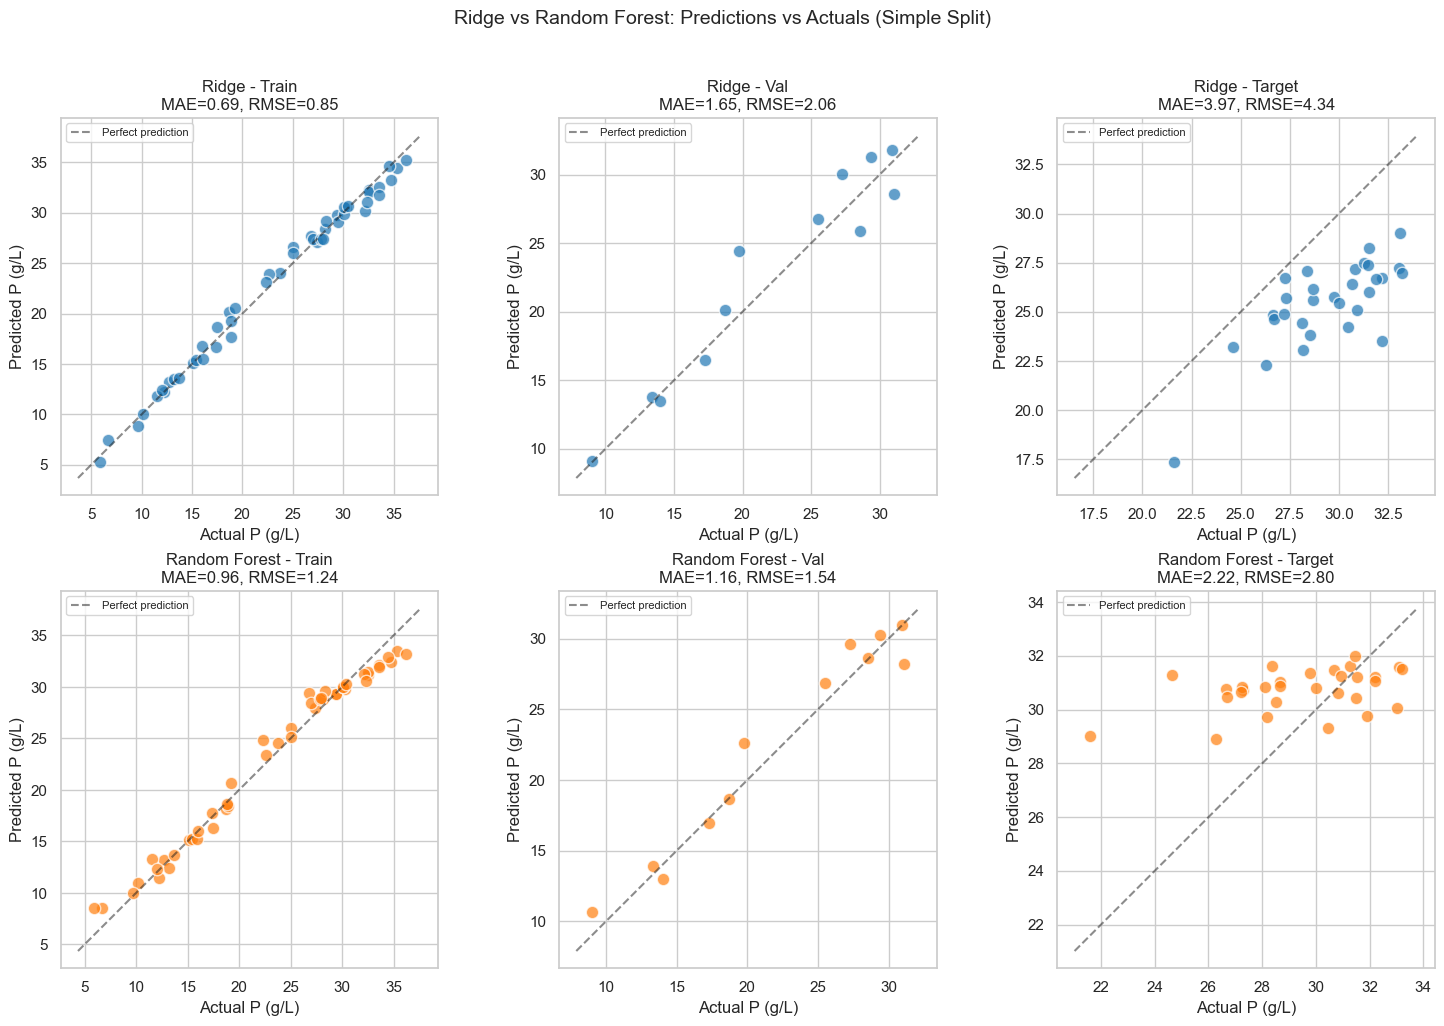

Saved to outputs/figures/ridge_vs_rf_simple_predictions.png


In [21]:
# Plot predictions vs actuals for Ridge and RF (simple train/val split)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Define plot data: (ax, title, y_true, y_pred, mae, rmse, color)
plot_data = [
    # Row 1: Ridge
    (axes[0, 0], "Ridge - Train", 
     ridge_results['train']['y_true'], ridge_results['train']['y_pred'], 
     ridge_results['train']['mae'], ridge_results['train']['rmse'], "tab:blue"),
    (axes[0, 1], "Ridge - Val", 
     ridge_results['val']['y_true'], ridge_results['val']['y_pred'], 
     ridge_results['val']['mae'], ridge_results['val']['rmse'], "tab:blue"),
    (axes[0, 2], "Ridge - Target", 
     ridge_results['target']['y_true'], ridge_results['target']['y_pred'], 
     ridge_results['target']['mae'], ridge_results['target']['rmse'], "tab:blue"),
    # Row 2: Random Forest
    (axes[1, 0], "Random Forest - Train", 
     rf_results['train']['y_true'], rf_results['train']['y_pred'], 
     rf_results['train']['mae'], rf_results['train']['rmse'], "tab:orange"),
    (axes[1, 1], "Random Forest - Val", 
     rf_results['val']['y_true'], rf_results['val']['y_pred'], 
     rf_results['val']['mae'], rf_results['val']['rmse'], "tab:orange"),
    (axes[1, 2], "Random Forest - Target", 
     rf_results['target']['y_true'], rf_results['target']['y_pred'], 
     rf_results['target']['mae'], rf_results['target']['rmse'], "tab:orange"),
]

for ax, title, y_true, y_pred, mae, rmse, color in plot_data:
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.7, color=color, edgecolor='white', s=80)
    
    # Perfect prediction line
    all_vals = np.concatenate([y_true, y_pred])
    min_val, max_val = all_vals.min(), all_vals.max()
    margin = (max_val - min_val) * 0.05
    ax.plot([min_val - margin, max_val + margin], 
            [min_val - margin, max_val + margin], 
            'k--', alpha=0.5, label='Perfect prediction')
    
    ax.set_xlabel("Actual P (g/L)")
    ax.set_ylabel("Predicted P (g/L)")
    ax.set_title(f"{title}\nMAE={mae:.2f}, RMSE={rmse:.2f}")
    ax.set_aspect('equal', 'box')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle("Ridge vs Random Forest: Predictions vs Actuals (Simple Split)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/ridge_vs_rf_simple_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/ridge_vs_rf_simple_predictions.png")

## 4. Cross-Validation Training

Train both Ridge and RF with cross-validation for more robust performance estimates.

In [22]:
# Cross-validation for Ridge
ridge_cv = RidgeBaseline(alpha=1.0)
ridge_cv_results = ridge_cv.fit_cv(
    batches,
    train_ids=source_ids,
    n_folds=5,
    alphas=[0.01, 0.1, 1.0, 10.0, 100.0],
    window_fraction=window_fraction,
    random_state=42,
)

print("Ridge Cross-Validation Results (5-fold)")
print("=" * 50)
print(f"CV MAE:  {ridge_cv_results['cv_mae']:.3f}")
print(f"CV RMSE: {ridge_cv_results['cv_rmse']:.3f}")
print(f"Best Alpha: {ridge_cv_results['best_alpha']}")

# Per-fold metrics
ridge_fold_df = pd.DataFrame(ridge_cv_results['fold_metrics'])
print(f"MAE: {ridge_fold_df['mae'].mean():.3f} +/- {ridge_fold_df['mae'].std():.3f}")

Ridge Cross-Validation Results (5-fold)
CV MAE:  1.683
CV RMSE: 2.120
Best Alpha: 10.0
MAE: 1.683 +/- 0.261


In [23]:
# Cross-validation for Random Forest (with best hyperparameters)
rf_cv = RandomForestBaseline(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42,
)
rf_cv_results = rf_cv.fit_cv(
    batches,
    train_ids=source_ids,
    n_folds=5,
    window_fraction=window_fraction,
    random_state=42,
)

print("Random Forest Cross-Validation Results (5-fold)")
print("=" * 50)
print(f"CV MAE:  {rf_cv_results['cv_mae']:.3f}")
print(f"CV RMSE: {rf_cv_results['cv_rmse']:.3f}")

# Per-fold metrics
rf_fold_df = pd.DataFrame(rf_cv_results['fold_metrics'])
print(f"MAE: {rf_fold_df['mae'].mean():.3f} +/- {rf_fold_df['mae'].std():.3f}")
print()

# Per-fold details
print("Per-Fold Results:")
print(rf_fold_df.round(3).to_string(index=False))

Random Forest Cross-Validation Results (5-fold)
CV MAE:  1.996
CV RMSE: 2.480
MAE: 1.996 +/- 0.579

Per-Fold Results:
 fold   mae  rmse  n_train  n_val
    1 1.303 1.570       48     12
    2 1.665 2.183       48     12
    3 2.034 2.406       48     12
    4 2.129 2.550       48     12
    5 2.851 3.349       48     12


In [24]:
# Evaluate CV-trained models on target domain
ridge_target_cv = ridge_cv.evaluate(batches, target_ids)
rf_target_cv = rf_cv.evaluate(batches, target_ids)

print("Cross-Validation Comparison: Ridge vs Random Forest")
print("=" * 60)
print(f"{'Metric':<25} {'Ridge':<15} {'Random Forest':<15}")
print("-" * 60)
print(f"{'CV MAE (Source)':<25} {ridge_cv_results['cv_mae']:<15.3f} {rf_cv_results['cv_mae']:<15.3f}")
print(f"{'CV MAE Std':<25} {ridge_fold_df['mae'].std():<15.3f} {rf_fold_df['mae'].std():<15.3f}")
print(f"{'Target MAE':<25} {ridge_target_cv['mae']:<15.3f} {rf_target_cv['mae']:<15.3f}")
print(f"{'Gap (Target - CV)':<25} {ridge_target_cv['mae'] - ridge_cv_results['cv_mae']:<15.3f} {rf_target_cv['mae'] - rf_cv_results['cv_mae']:<15.3f}")
print("=" * 60)

Cross-Validation Comparison: Ridge vs Random Forest
Metric                    Ridge           Random Forest  
------------------------------------------------------------
CV MAE (Source)           1.683           1.996          
CV MAE Std                0.261           0.579          
Target MAE                57.715          2.748          
Gap (Target - CV)         56.032          0.752          


### Visualize CV Predictions: Ridge vs Random Forest

Compare out-of-fold predictions (source CV) and target predictions for both models.

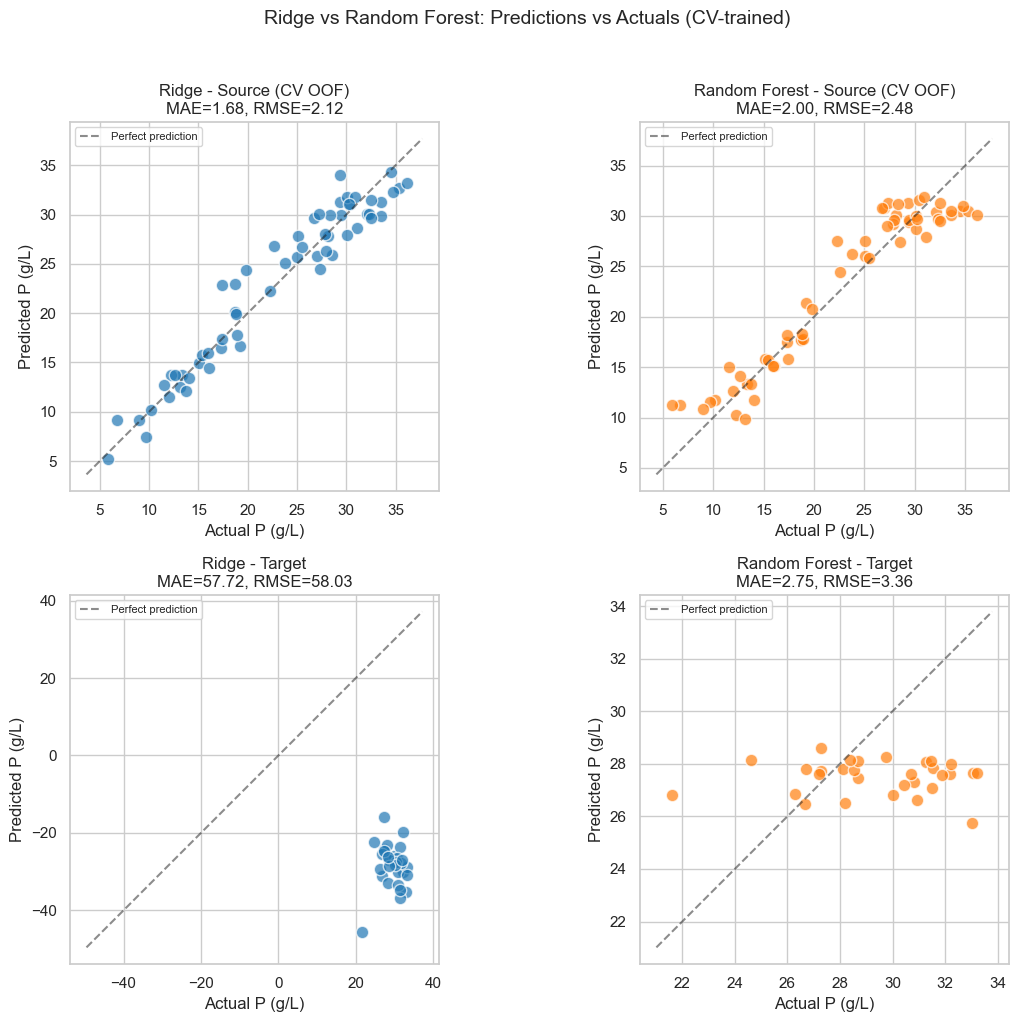

Saved to outputs/figures/ridge_vs_rf_cv_predictions.png


In [25]:
# Plot predictions vs actuals for Ridge and RF (CV-trained models)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Data for plotting
plot_data = [
    # Row 1: Out-of-fold (Source CV) predictions
    (axes[0, 0], "Ridge - Source (CV OOF)", 
     ridge_cv_results['y_true'], ridge_cv_results['oof_predictions'], 
     ridge_cv_results['cv_mae'], ridge_cv_results['cv_rmse'], "tab:blue"),
    (axes[0, 1], "Random Forest - Source (CV OOF)", 
     rf_cv_results['y_true'], rf_cv_results['oof_predictions'], 
     rf_cv_results['cv_mae'], rf_cv_results['cv_rmse'], "tab:orange"),
    # Row 2: Target predictions
    (axes[1, 0], "Ridge - Target", 
     ridge_target_cv['y_true'], ridge_target_cv['y_pred'], 
     ridge_target_cv['mae'], ridge_target_cv['rmse'], "tab:blue"),
    (axes[1, 1], "Random Forest - Target", 
     rf_target_cv['y_true'], rf_target_cv['y_pred'], 
     rf_target_cv['mae'], rf_target_cv['rmse'], "tab:orange"),
]

for ax, title, y_true, y_pred, mae, rmse, color in plot_data:
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.7, color=color, edgecolor='white', s=80)
    
    # Perfect prediction line
    all_vals = np.concatenate([y_true, y_pred])
    min_val, max_val = all_vals.min(), all_vals.max()
    margin = (max_val - min_val) * 0.05
    ax.plot([min_val - margin, max_val + margin], 
            [min_val - margin, max_val + margin], 
            'k--', alpha=0.5, label='Perfect prediction')
    
    ax.set_xlabel("Actual P (g/L)")
    ax.set_ylabel("Predicted P (g/L)")
    ax.set_title(f"{title}\nMAE={mae:.2f}, RMSE={rmse:.2f}")
    ax.set_aspect('equal', 'box')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle("Ridge vs Random Forest: Predictions vs Actuals (CV-trained)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/ridge_vs_rf_cv_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/ridge_vs_rf_cv_predictions.png")

## 5. Ridge vs Random Forest Comparison

In [26]:
# Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["Ridge", "Ridge", "Ridge", "Random Forest", "Random Forest", "Random Forest"],
    "Split": ["Train", "Val", "Target", "Train", "Val", "Target"],
    "MAE": [
        ridge_results["train"]["mae"],
        ridge_results["val"]["mae"],
        ridge_results["target"]["mae"],
        rf_results["train"]["mae"],
        rf_results["val"]["mae"],
        rf_results["target"]["mae"],
    ],
    "RMSE": [
        ridge_results["train"]["rmse"],
        ridge_results["val"]["rmse"],
        ridge_results["target"]["rmse"],
        rf_results["train"]["rmse"],
        rf_results["val"]["rmse"],
        rf_results["target"]["rmse"],
    ],
})

# Pivot for cleaner display
comparison_pivot = comparison_df.pivot(index="Split", columns="Model", values=["MAE", "RMSE"])
comparison_pivot = comparison_pivot.round(3)
print("Ridge vs Random Forest Comparison:")
print(comparison_pivot)

Ridge vs Random Forest Comparison:
                 MAE                 RMSE       
Model  Random Forest  Ridge Random Forest  Ridge
Split                                           
Target         2.216  3.966         2.801  4.341
Train          0.964  0.685         1.239  0.847
Val            1.162  1.647         1.541  2.064


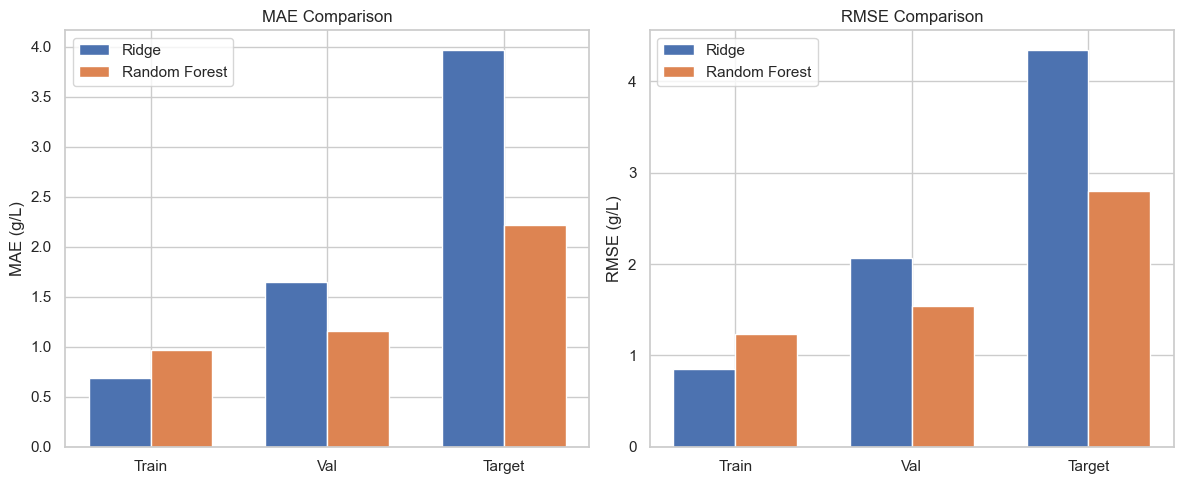

In [27]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE comparison
ax = axes[0]
x = np.arange(3)
width = 0.35
splits = ["Train", "Val", "Target"]
ridge_mae = [ridge_results["train"]["mae"], ridge_results["val"]["mae"], ridge_results["target"]["mae"]]
rf_mae = [rf_results["train"]["mae"], rf_results["val"]["mae"], rf_results["target"]["mae"]]

ax.bar(x - width/2, ridge_mae, width, label='Ridge')
ax.bar(x + width/2, rf_mae, width, label='Random Forest')
ax.set_ylabel('MAE (g/L)')
ax.set_title('MAE Comparison')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()

# RMSE comparison
ax = axes[1]
ridge_rmse = [ridge_results["train"]["rmse"], ridge_results["val"]["rmse"], ridge_results["target"]["rmse"]]
rf_rmse = [rf_results["train"]["rmse"], rf_results["val"]["rmse"], rf_results["target"]["rmse"]]

ax.bar(x - width/2, ridge_rmse, width, label='Ridge')
ax.bar(x + width/2, rf_rmse, width, label='Random Forest')
ax.set_ylabel('RMSE (g/L)')
ax.set_title('RMSE Comparison')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/ridge_vs_rf_comparison.png', dpi=150)
plt.show()

## 6. Feature Importance Analysis

In [28]:
# Compute permutation importance on validation set
importance_df = compute_permutation_importance(
    rf_results["model"],
    batches,
    val_ids,
    window_fraction=window_fraction,
    n_repeats=10,
)

# Get ranked features
ranked_importance = get_feature_importance_ranking(importance_df)
print("Feature Importance Ranking (Top 15):")
print(ranked_importance.head(15).to_string(index=False))

Feature Importance Ranking (Top 15):
          feature  importance_mean  importance_std  rank
          S_slope         0.020860        0.009986     1
PAA_offline_slope         0.016737        0.009113     2
            S_std         0.015577        0.007883     3
           Fa_std         0.015246        0.010287     4
  PAA_offline_std         0.012501        0.007451     5
  PAA_offline_max         0.011823        0.007284     6
           S_mean         0.008720        0.004728     7
  NH3_offline_std         0.008168        0.006488     8
          Fa_mean         0.007267        0.004917     9
            S_max         0.004645        0.003323    10
 PAA_offline_mean         0.003772        0.003878    11
NH3_offline_slope         0.003142        0.003371    12
        DO2_slope         0.003002        0.003350    13
          pH_mean         0.002811        0.001982    14
           Fa_max         0.002087        0.004878    15


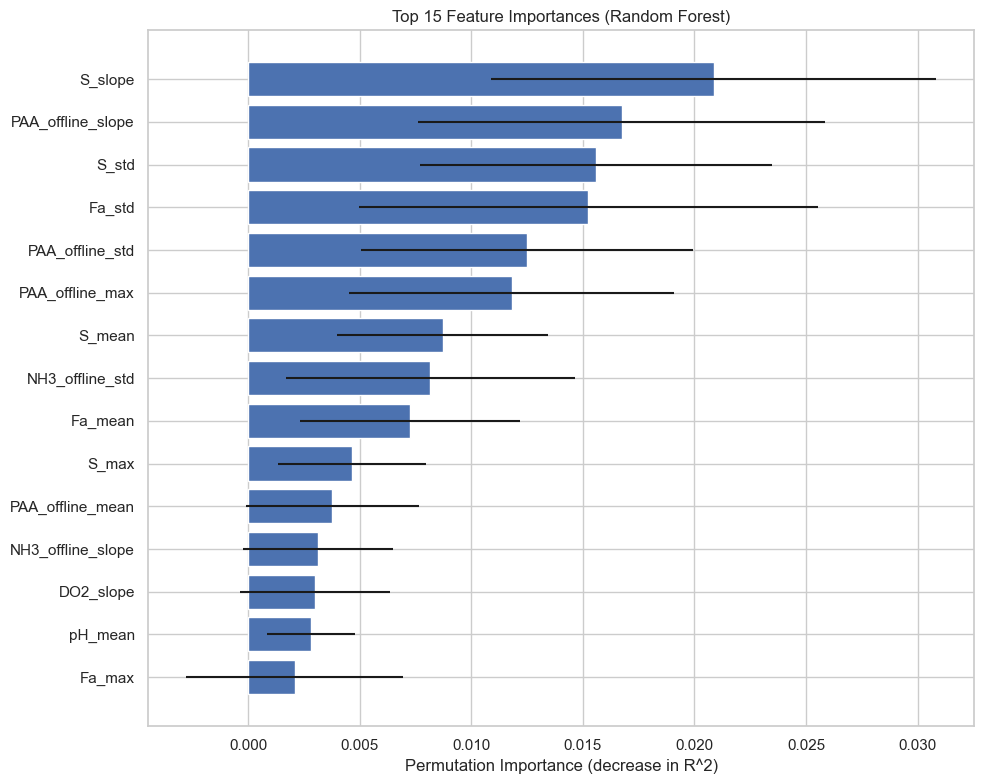

In [29]:
# Plot top 15 feature importances
top_n = 15
top_features = ranked_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(top_n)

ax.barh(y_pos, top_features["importance_mean"], xerr=top_features["importance_std"], align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features["feature"])
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Permutation Importance (decrease in R^2)')
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)')

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()

In [30]:
# Save feature importance to CSV
ranked_importance.to_csv('../outputs/feature_importance.csv', index=False)
print("Saved feature importance to outputs/feature_importance.csv")

Saved feature importance to outputs/feature_importance.csv


## 6. Feature Importance by Variable

In [31]:
# Aggregate importance by original variable (sum across stats)
ranked_importance["variable"] = ranked_importance["feature"].str.rsplit("_", n=1).str[0]
variable_importance = ranked_importance.groupby("variable")["importance_mean"].sum().sort_values(ascending=False)

print("Aggregated Importance by Variable:")
print(variable_importance.round(4))

Aggregated Importance by Variable:
variable
S                    0.0487
PAA_offline          0.0450
Fa                   0.0246
NH3_offline          0.0131
DO2                  0.0052
pH                   0.0025
OUR                  0.0012
Fb                   0.0010
Wt                   0.0010
CER                  0.0008
X_offline            0.0008
Fs                   0.0004
O2                   0.0003
CO2outgas            0.0003
Fc                   0.0002
Fg                   0.0001
Fw                   0.0001
pressure             0.0000
Foil                -0.0001
Fremoved            -0.0003
Fpaa                -0.0003
V                   -0.0004
T                   -0.0008
Viscosity_offline   -0.0009
Fh                  -0.0023
Name: importance_mean, dtype: float64


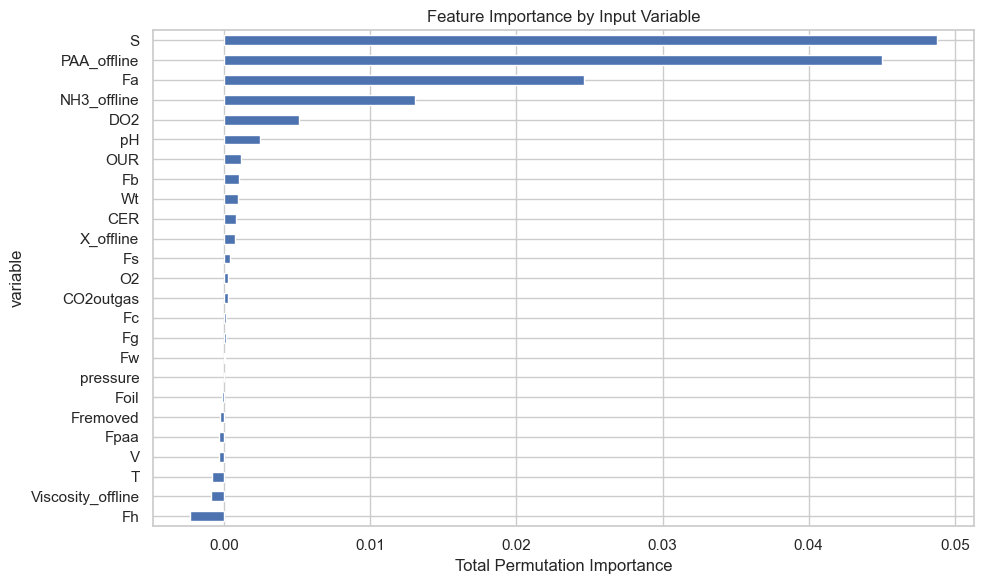

In [32]:
# Plot importance by variable
fig, ax = plt.subplots(figsize=(10, 6))
variable_importance.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Total Permutation Importance')
ax.set_title('Feature Importance by Input Variable')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_by_variable.png', dpi=150)
plt.show()

## Summary

**Random Forest vs Ridge:**
- Random Forest can capture non-linear relationships
- Compare overfitting (train vs val gap) between models
- Domain shift impact on both models

**Feature Importance Insights:**
- Top features indicate which process variables are most predictive
- Aggregated variable importance shows overall signal relevance
- Feature importance can guide feature selection for transformer models